# Comparing Machine Learning Algorithms for Brain Stroke Detection

## Problem Defintion

One of the most exciting application of Machine Leanring is the disease detection. There have already been previous research on utilizing data from patients in order to determine whether the person was likely to have a disease or not. 

In this project, we are going to be comparing these 6 machine learning algorithms to see which one can predict brain strokes the best based on accuracy, precision, recall, and F1 score. 

The 6 different algorithms are K-Nearest Neighbors, Logistic Regression, Random Forest, Support Vector Machine, Extreme Gradient Boost, and CatBoost



# Exploratory Data Analysis

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik

In [41]:
# Load Dataset
df = pd.read_csv('data/full_filled_stroke_data.csv')

In [42]:
# Show first 10 rows of the dataset
print(df.shape)
df.head(10)

(201, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,31.555602,never smoked,1
1,Female,59.0,0,0,Yes,Private,Rural,76.15,30.242937,Unknown,1
2,Male,78.0,0,1,Yes,Private,Urban,219.84,30.698951,Unknown,1
3,Male,57.0,0,1,No,Govt_job,Urban,217.08,33.808410,Unknown,1
4,Male,58.0,0,0,Yes,Private,Rural,189.84,31.378534,Unknown,1
5,Male,59.0,0,0,Yes,Private,Rural,211.78,33.484568,formerly smoked,1
6,Female,63.0,0,0,Yes,Private,Urban,90.90,30.042545,formerly smoked,1
7,Female,75.0,0,1,No,Self-employed,Urban,109.78,28.318273,Unknown,1
8,Female,76.0,0,0,No,Private,Urban,89.96,28.397893,Unknown,1
9,Male,78.0,1,0,Yes,Private,Urban,75.32,29.139780,formerly smoked,1


In [24]:
# Null Values
null_values = df.isnull().sum()
print(f"Null Values in the Data:\n{null_values}")
print()

# Summary Statistics
df.describe()

Null Values in the Data:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64



,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,52.049154,0.233831,0.164179,126.724627,29.336870,0.199005
std,22.276181,0.424323,0.371363,59.240322,3.363098,0.400249
min,0.480000,0.000000,0.000000,57.520000,17.899295,0.000000
25%,37.000000,0.000000,0.000000,81.430000,28.397893,0.000000
50%,58.000000,0.000000,0.000000,99.870000,29.948147,0.000000
75%,71.000000,0.000000,0.000000,191.790000,31.378534,0.000000
max,82.000000,1.000000,1.000000,260.850000,35.188605,1.000000


From the results above, there are no missing values, which is vry fortunate for us as this is usually not the case when utilizing real-world data

In [29]:
# See the class distribution of labels
df['stroke'].value_counts()

stroke
0    161
1     40
Name: count, dtype: int64

From the result above, you can see that we have an imbalance where the minority class is the people with strokes.

We will need to address this either using SMOTE or Cost-Sensitive Learning because in our case, we want to have more examples of the minority class for our models to understand the cases where people have brain strokes.

In [28]:
# Features and their types
features = df.drop(columns='stroke')
labels = df['stroke']

numeric_features = features.select_dtypes(include=['int', 'float']).columns.to_list()
categorical_features = features.select_dtypes(exclude=['int', 'float']).columns.to_list()

print(f'Numerical Features: {numeric_features}')
print()
print(f'Categorical Features: {categorical_features}')
print()

# The unique values in each categorical feature to determine whether they are nomial or ordinal
for column in categorical_features:
    unique_values = sorted(features[column].unique())
    print(f"The Unique Values in {column} are: {unique_values}")
    print()

Numerical Features: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

Categorical Features: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

The Unique Values in gender are: ['Female', 'Male']

The Unique Values in ever_married are: ['No', 'Yes']

The Unique Values in work_type are: ['Govt_job', 'Private', 'Self-employed', 'children']

The Unique Values in Residence_type are: ['Rural', 'Urban']

The Unique Values in smoking_status are: ['Unknown', 'formerly smoked', 'never smoked', 'smokes']



From the results above, the only categorical feature that could be a smoking status. However, The ordinal order of it will be interesting because Unknown means it be anyting in terms of amount of smoking. 

The ordering might be 'never smoked', 'Unknown', 'formerly smoked', and 'smokes'. 

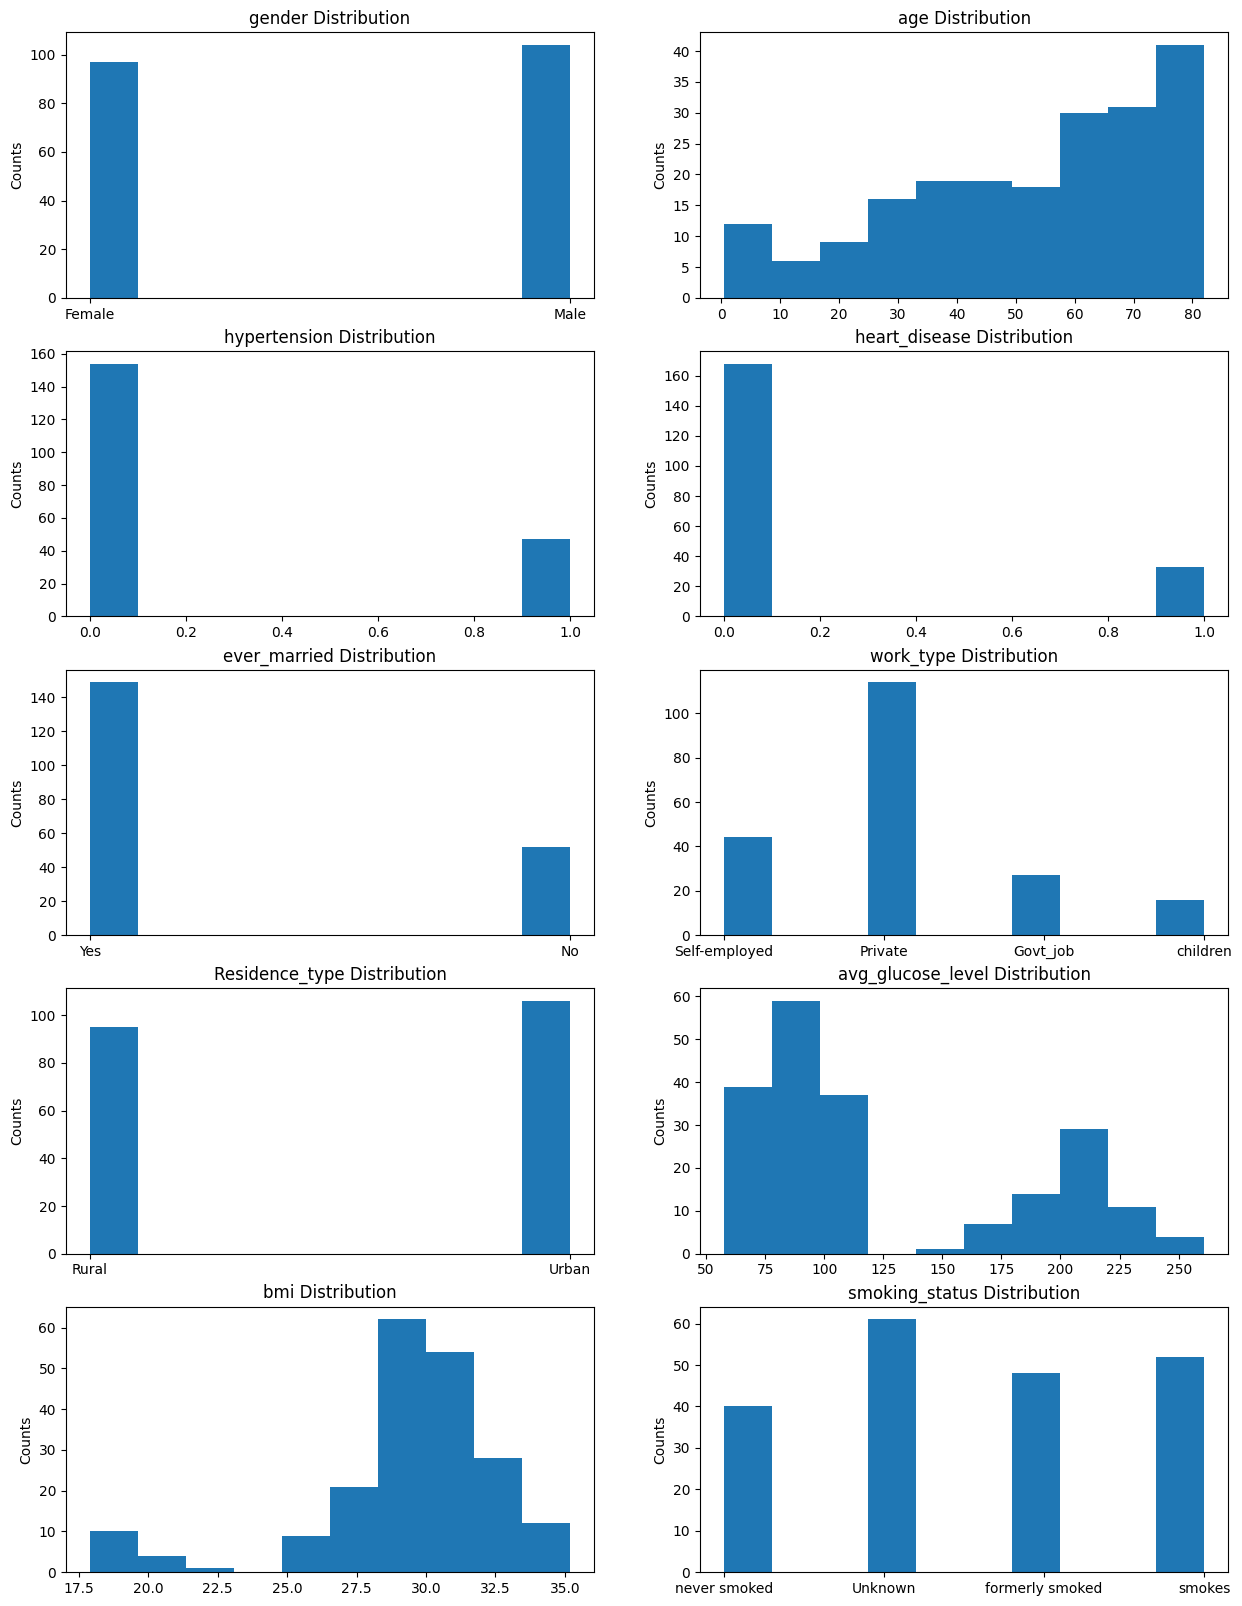

In [ ]:
# Distribution of features
fig, axes = plt.subplots(5, 2, figsize=(15,20))

flat_axes = axes.flatten()

for column, ax in zip(features.columns, flat_axes):
    ax.hist(df[column])
    ax.set_ylabel("Counts")
    ax.set_title(f"{column} Distribution")

fig.savefig(fname='features_distributions.png')

From the histograms above, we can see Hypertension, Ever Married, and Heart Disease features have a lot of imbalance, as they skew right.

The average glucose levels and bmi distibutions are very similar but in reverse, where one part looks normally distribution and another part is separate. 

The smoking status and gender distributions is fairly well balanced. 

The Age distributions skew slightly left, which makes sense since the older 
an individual is, the more likely the person will have brain stroke.



age                  0.353495
hypertension        -0.098721
heart_disease        0.014560
avg_glucose_level   -0.040227
bmi                  0.003663
dtype: float64

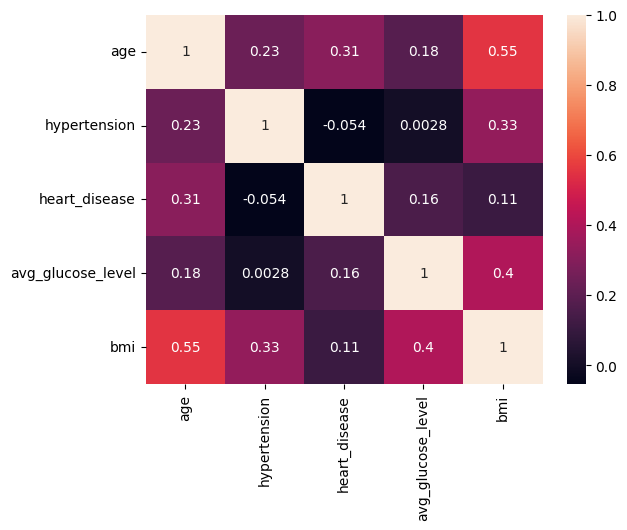

In [92]:
# Correlation Matrix for numerical features with each other
num_features = features.select_dtypes(include=['int', 'float'])
correlation = sns.heatmap(num_features.corr(), annot=True)
figure = correlation.get_figure()
figure.savefig(fname="correlation_heatmap.png")

# How correlated are numerical features to the label
num_features.corrwith(labels)

From the data, it looks like age has the highest correlation to having a brain stroke, which makes sense since older people usually suffer strokes just in general. 

From the Heatmap, bmi and age have the biggest correlation, followed by heart disease and age, and hypertension and age.